# 03. Deep Sequence Models Under the Same Split Rule

**By the end of this notebook you should understand**
- how the codex deep study is trained and evaluated
- where RNN / GRU / LSTM help on the representative cases
- how deep models compare to classical ones on the shared benchmark


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import copy
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from codex_notebooks.support import (
    CODEX_DIR,
    LOOKBACK,
    apply_plot_style,
    build_codex_artifacts,
    chronological_split_df,
    export_figure,
    load_artifact,
    load_study_series,
    mase,
    weighted_mae,
    weighted_rmse,
    weighted_skill,
)

warnings.filterwarnings('ignore')
apply_plot_style()
build_codex_artifacts(force=False, verbose=False)

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cpu')
MAX_EPOCHS = 20
PATIENCE = 4
HIDDEN_SIZE = 24
BATCH_SIZE = 32
LR = 1e-3

chosen = load_artifact('chosen_manifest.parquet')
benchmark = load_artifact('benchmark_manifest.parquet')
study_series = load_study_series()
series_frames = {
    series_id: frame.sort_values('ts_index').reset_index(drop=True)
    for series_id, frame in study_series.groupby('series_id')
}

RESULTS_PATH = CODEX_DIR / 'deep_results.parquet'
FORECASTS_PATH = CODEX_DIR / 'deep_forecasts.parquet'


## 1. Model setup

This is intentionally modest and class-teachable:
- target history only
- one-step training windows
- recursive multi-step validation forecasts
- `RNN`, `GRU`, and `LSTM`


In [2]:
MODEL_NAMES = ['Naive', 'RNN', 'GRU', 'LSTM']


def make_windows(values, lookback=LOOKBACK):
    values = np.asarray(values, dtype=np.float32)
    X, y = [], []
    for i in range(len(values) - lookback):
        X.append(values[i:i + lookback])
        y.append(values[i + lookback])
    return np.asarray(X), np.asarray(y)


class RecurrentRegressor(nn.Module):
    def __init__(self, kind, hidden_size=HIDDEN_SIZE):
        super().__init__()
        if kind == 'RNN':
            self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif kind == 'GRU':
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif kind == 'LSTM':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            raise KeyError(kind)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


def fit_recurrent(kind, train_values):
    mean = float(np.mean(train_values))
    std = float(np.std(train_values))
    if std < 1e-8:
        std = 1.0

    scaled = (np.asarray(train_values, dtype=np.float32) - mean) / std
    X, y = make_windows(scaled)
    if len(X) < 8:
        raise ValueError('not enough windows')

    split = max(1, int(len(X) * 0.8))
    train_X = torch.tensor(X[:split]).unsqueeze(-1)
    train_y = torch.tensor(y[:split])
    val_X = torch.tensor(X[split:]).unsqueeze(-1) if split < len(X) else train_X[-1:].clone()
    val_y = torch.tensor(y[split:]) if split < len(X) else train_y[-1:].clone()

    loader = DataLoader(TensorDataset(train_X, train_y), batch_size=min(BATCH_SIZE, len(train_X)), shuffle=True)
    model = RecurrentRegressor(kind).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    best_state = None
    best_val = float('inf')
    wait = 0

    for epoch in range(MAX_EPOCHS):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(val_X.to(DEVICE))
            val_loss = float(loss_fn(val_pred, val_y.to(DEVICE)).item())

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, mean, std


def recursive_forecast(model, train_values, steps, mean, std):
    context = list(((np.asarray(train_values, dtype=np.float32) - mean) / std).tolist())
    preds = []
    model.eval()
    with torch.no_grad():
        for _ in range(steps):
            x = torch.tensor(context[-LOOKBACK:], dtype=torch.float32).view(1, LOOKBACK, 1).to(DEVICE)
            pred_scaled = float(model(x).cpu().item())
            preds.append(pred_scaled * std + mean)
            context.append(pred_scaled)
    return np.asarray(preds, dtype=float)


In [3]:
def evaluate_deep_series(series_id, frame, role, label):
    train_part, val_part, info = chronological_split_df(frame[['ts_index', 'y_target', 'weight']])
    rows = []
    forecast_rows = []

    naive_pred = np.repeat(train_part['y_target'].iloc[-1], len(val_part))
    rows.append(
        {
            'series_id': series_id,
            'role': role,
            'label': label,
            'model': 'Naive',
            'train_len': info.train_len,
            'val_len': info.val_len,
            'status': 'ok',
            'skill_score': weighted_skill(val_part['y_target'], naive_pred, val_part['weight']),
            'rmse': weighted_rmse(val_part['y_target'], naive_pred, val_part['weight']),
            'mae': weighted_mae(val_part['y_target'], naive_pred, val_part['weight']),
            'mase': mase(val_part['y_target'], naive_pred, train_part['y_target']),
        }
    )
    for ts_index, y_true, y_pred in zip(val_part['ts_index'], val_part['y_target'], naive_pred):
        forecast_rows.append({'series_id': series_id, 'role': role, 'label': label, 'model': 'Naive', 'ts_index': ts_index, 'y_true': y_true, 'y_pred': y_pred})

    for kind in ['RNN', 'GRU', 'LSTM']:
        try:
            model, mean, std = fit_recurrent(kind, train_part['y_target'].to_numpy())
            pred = recursive_forecast(model, train_part['y_target'].to_numpy(), len(val_part), mean, std)
            status = 'ok'
        except Exception as exc:
            pred = np.repeat(np.nan, len(val_part))
            status = f'error: {type(exc).__name__}'

        rows.append(
            {
                'series_id': series_id,
                'role': role,
                'label': label,
                'model': kind,
                'train_len': info.train_len,
                'val_len': info.val_len,
                'status': status,
                'skill_score': weighted_skill(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'rmse': weighted_rmse(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'mae': weighted_mae(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'mase': mase(val_part['y_target'], pred, train_part['y_target']) if status == 'ok' else np.nan,
            }
        )
        for ts_index, y_true, y_pred in zip(val_part['ts_index'], val_part['y_target'], pred):
            forecast_rows.append({'series_id': series_id, 'role': role, 'label': label, 'model': kind, 'ts_index': ts_index, 'y_true': y_true, 'y_pred': y_pred})
    return rows, forecast_rows


In [4]:
if RESULTS_PATH.exists() and FORECASTS_PATH.exists():
    results = pd.read_parquet(RESULTS_PATH)
    forecasts = pd.read_parquet(FORECASTS_PATH)
else:
    result_rows = []
    forecast_rows = []

    reps = chosen[['series_id', 'reason']].copy().rename(columns={'reason': 'label'})
    bench = benchmark[['series_id', 'benchmark_band']].copy().rename(columns={'benchmark_band': 'label'})

    for _, row in reps.iterrows():
        r_rows, f_rows = evaluate_deep_series(row['series_id'], series_frames[row['series_id']], 'representative', row['label'])
        result_rows.extend(r_rows)
        forecast_rows.extend(f_rows)

    for _, row in bench.iterrows():
        r_rows, f_rows = evaluate_deep_series(row['series_id'], series_frames[row['series_id']], 'benchmark', row['label'])
        result_rows.extend(r_rows)
        forecast_rows.extend(f_rows)

    results = pd.DataFrame(result_rows)
    forecasts = pd.DataFrame(forecast_rows)
    results.to_parquet(RESULTS_PATH, index=False)
    forecasts.to_parquet(FORECASTS_PATH, index=False)

ok_results = results[results['status'] == 'ok'].copy()
best_by_series = ok_results.sort_values(['series_id', 'skill_score'], ascending=[True, False]).groupby('series_id').head(1)


## 2. Representative-series results


In [5]:
rep_summary = ok_results[ok_results['role'] == 'representative'].pivot_table(
    index='label',
    columns='model',
    values='skill_score'
).round(3)
display(rep_summary)


model,GRU,LSTM,Naive,RNN
label,,,,
highest total weight,0.470,0.436,0.440,0.497
longest history,0.032,0.000,0.000,0.031
most stable,0.130,0.000,0.000,0.000
most volatile,0.076,0.833,0.671,0.856


**Final deck figure:** `03_deep_forecasts.png`


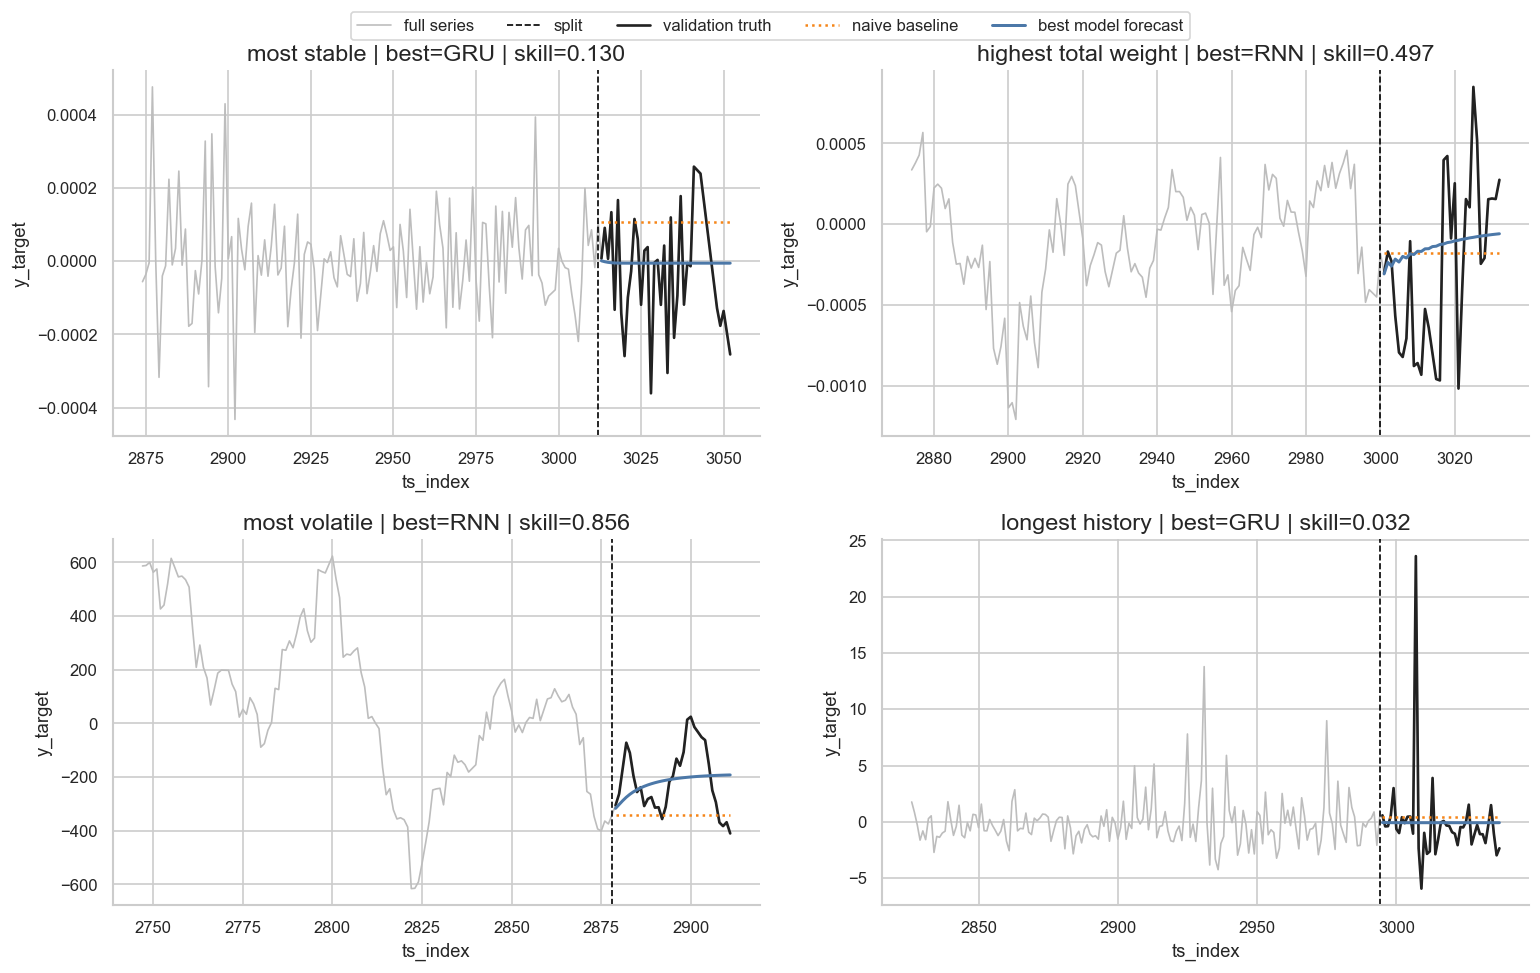

In [6]:
rep_best = best_by_series[best_by_series['role'] == 'representative'].copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
axes = axes.flatten()

for ax, (_, row) in zip(axes, rep_best.iterrows()):
    full_series = series_frames[row['series_id']].sort_values('ts_index').reset_index(drop=True)
    train_part, val_part, info = chronological_split_df(full_series[['ts_index', 'y_target', 'weight']])
    naive_pred = forecasts[(forecasts['series_id'] == row['series_id']) & (forecasts['model'] == 'Naive')]
    best_pred = forecasts[(forecasts['series_id'] == row['series_id']) & (forecasts['model'] == row['model'])]

    ax.plot(full_series['ts_index'], full_series['y_target'], color='#bdbdbd', linewidth=1.0, label='full series')
    ax.axvline(train_part['ts_index'].iloc[-1], color='black', linestyle='--', linewidth=1, label='split')
    ax.plot(val_part['ts_index'], val_part['y_target'], color='#222222', linewidth=1.6, label='validation truth')
    ax.plot(naive_pred['ts_index'], naive_pred['y_pred'], color='#F58518', linestyle=':', linewidth=1.5, label='naive baseline')
    ax.plot(best_pred['ts_index'], best_pred['y_pred'], color='#4C78A8', linewidth=1.8, label='best model forecast')
    ax.set_title(f"{row['label']} | best={row['model']} | skill={row['skill_score']:.3f}")
    ax.set_xlabel('ts_index')
    ax.set_ylabel('y_target')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
export_figure(fig, '03_deep_forecasts.png')
plt.show()


## 3. Broader benchmark

**Final deck figure:** `03_deep_benchmark_skill.png`


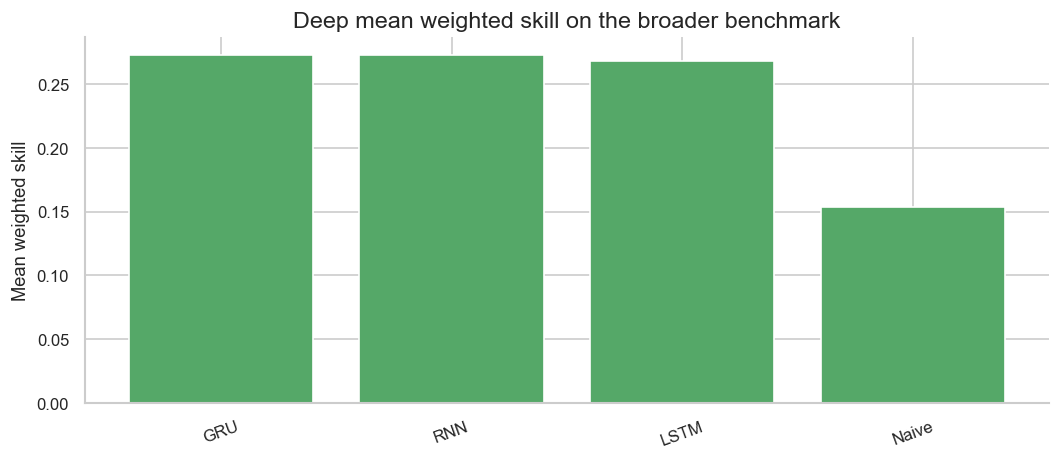

,model,mean_skill,median_skill,mean_rmse
0,GRU,0.273142,0.147865,0.870120
1,RNN,0.272845,0.101397,0.877792
2,LSTM,0.268007,0.149205,0.862903
3,Naive,0.153569,0.000000,1.052259


In [7]:
benchmark_summary = (
    ok_results[ok_results['role'] == 'benchmark']
    .groupby('model')
    .agg(
        mean_skill=('skill_score', 'mean'),
        median_skill=('skill_score', 'median'),
        mean_rmse=('rmse', 'mean'),
    )
    .sort_values('mean_skill', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(benchmark_summary['model'], benchmark_summary['mean_skill'], color='#55A868')
ax.set_title('Deep mean weighted skill on the broader benchmark')
ax.set_ylabel('Mean weighted skill')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
export_figure(fig, '03_deep_benchmark_skill.png')
plt.show()

benchmark_summary


## 4. Shared-benchmark comparison to classical

Because `02_classical` and `03_deep` use the same split rule and the same benchmark series, we can compare them directly here.

**Final deck figure:** `03_classical_vs_deep_benchmark.png`


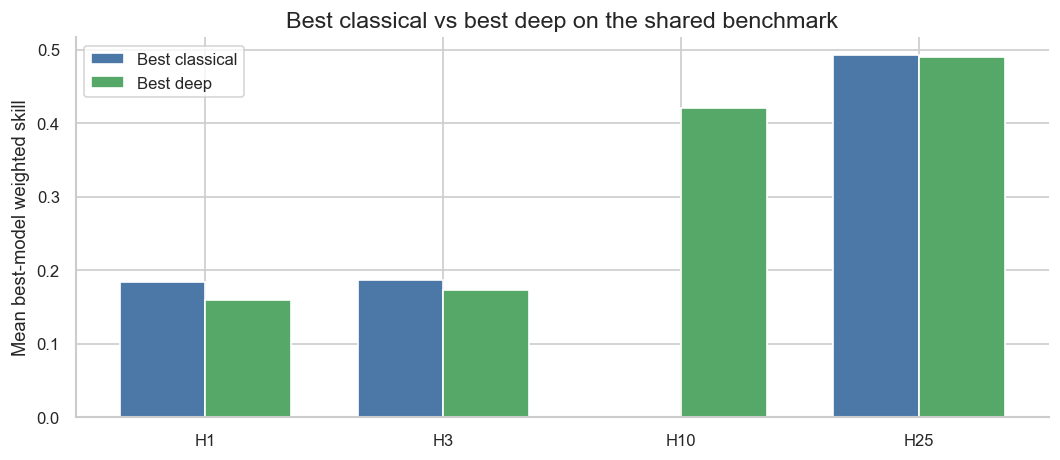

,horizon,best_classical,best_deep
0,1,0.183351,0.160050
1,3,0.186947,0.172942
2,10,0.000000,0.420676
3,25,0.492109,0.490206


In [8]:
classical_results = pd.read_parquet(CODEX_DIR / 'classical_results.parquet')
classical_ok = classical_results[classical_results['status'] == 'ok']

classical_best = classical_ok[classical_ok['role'] == 'benchmark'].sort_values(['series_id', 'skill_score'], ascending=[True, False]).groupby('series_id').head(1)
deep_best = ok_results[ok_results['role'] == 'benchmark'].sort_values(['series_id', 'skill_score'], ascending=[True, False]).groupby('series_id').head(1)

compare = (
    benchmark[['series_id', 'horizon']]
    .merge(classical_best[['series_id', 'skill_score']].rename(columns={'skill_score': 'best_classical'}), on='series_id', how='left')
    .merge(deep_best[['series_id', 'skill_score']].rename(columns={'skill_score': 'best_deep'}), on='series_id', how='left')
)

compare_summary = compare.groupby('horizon')[['best_classical', 'best_deep']].mean().reset_index()

x = np.arange(len(compare_summary))
width = 0.36
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, compare_summary['best_classical'], width=width, color='#4C78A8', label='Best classical')
ax.bar(x + width / 2, compare_summary['best_deep'], width=width, color='#55A868', label='Best deep')
ax.set_xticks(x)
ax.set_xticklabels([f"H{int(h)}" for h in compare_summary['horizon']])
ax.set_ylabel('Mean best-model weighted skill')
ax.set_title('Best classical vs best deep on the shared benchmark')
ax.legend()
fig.tight_layout()
export_figure(fig, '03_classical_vs_deep_benchmark.png')
plt.show()

compare_summary


## 5. What we learned

- the deep notebook now shares the same split rule as the classical notebook
- target-history recurrent models can be compared honestly against classical models on the shared benchmark
- the representative cases still matter for intuition, but the benchmark prevents over-claiming

## What changes next

The codex notebook phase is complete when these notebooks are runnable, explain the project clearly, and export the figures needed for the Beamer deck.
